<a href="https://colab.research.google.com/github/rzjuliannofficial/PCVK_18_Julian/blob/main/PCVK_W5_2341720255_Nabhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, platform, hashlib, datetime, zoneinfo
import matplotlib.pyplot as plt
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob
from pathlib import Path

PATH = '/content/drive/MyDrive/Kuliah/Semester5/PCVK/Img'

# **IDENTITAS**

NAMA : Nabhan Rizqi Julian Saputro
NIM : 2341720255 | N = 255
bins   : 64
clip   : 1.0
tile   : 5
L      : 2
WAKTU : 2026-09-21 14:18:27 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : b1dde8c147ab26ed


Text(0.5, 1.0, '2341720255 - CLAHE clip 1.0')

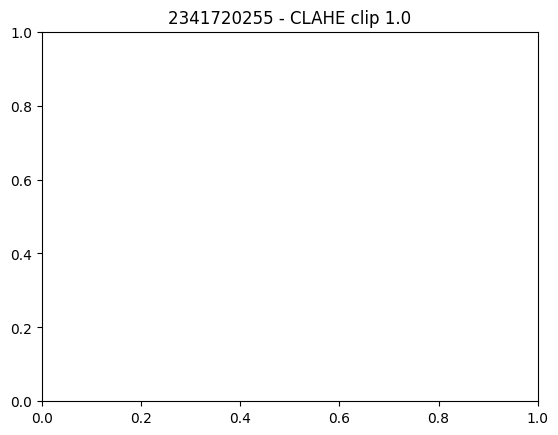

In [ ]:
NAMA = 'Nabhan Rizqi Julian Saputro'
NIM = '2341720255'
N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

# **E-1 PERCOBAAN HISTOGRAM**

<BarContainer object of 256 artists>

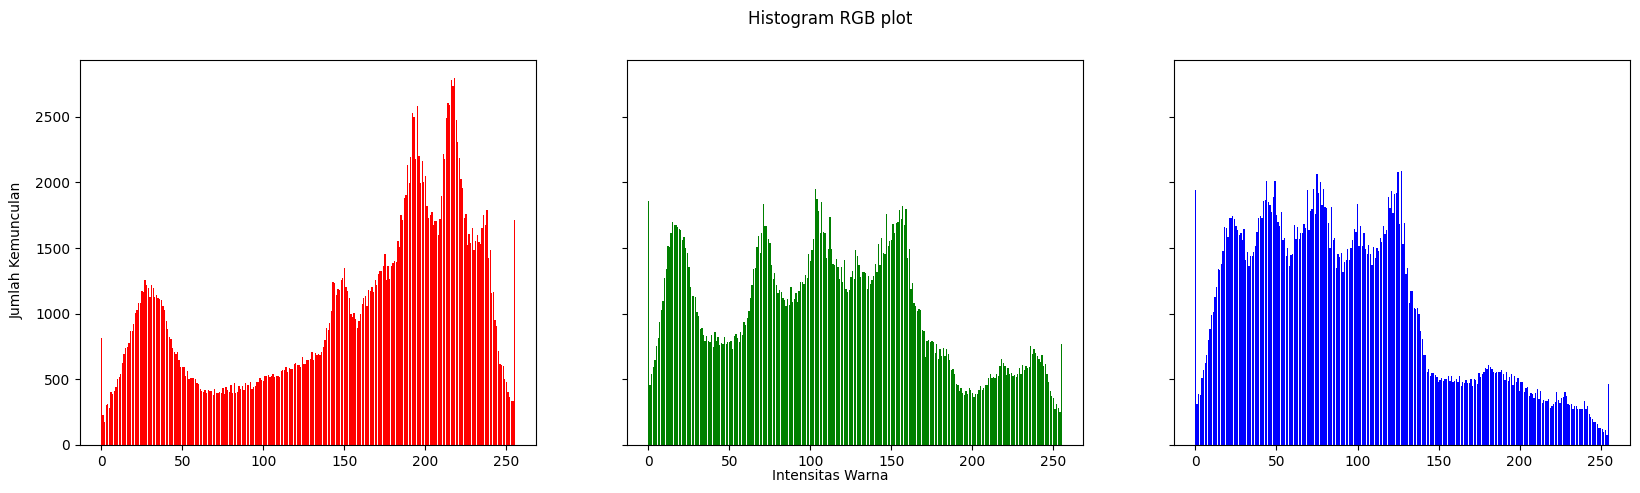

In [ ]:
#membuat histogram image (manual)
img = cv.imread(PATH / "lena.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0,height):
  for x in range(0,width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## **PERTANYAAN PRAKTIKUM E1**

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.


===== Memulai Pemrosesan Citra lena.jpg =====
Menghitung histogram untuk lena.jpg...

--- Perbandingan Histogram untuk lena.jpg ---

Channel Merah:
  Selisih Maksimum (Manual vs NumPy): 0
  Selisih Maksimum (Manual vs OpenCV): 0.0
  Pembuktian berhasil: Selisih untuk channel Merah adalah nol.

Channel Hijau:
  Selisih Maksimum (Manual vs NumPy): 0
  Selisih Maksimum (Manual vs OpenCV): 0.0
  Pembuktian berhasil: Selisih untuk channel Hijau adalah nol.

Channel Biru:
  Selisih Maksimum (Manual vs NumPy): 0
  Selisih Maksimum (Manual vs OpenCV): 0.0
  Pembuktian berhasil: Selisih untuk channel Biru adalah nol.


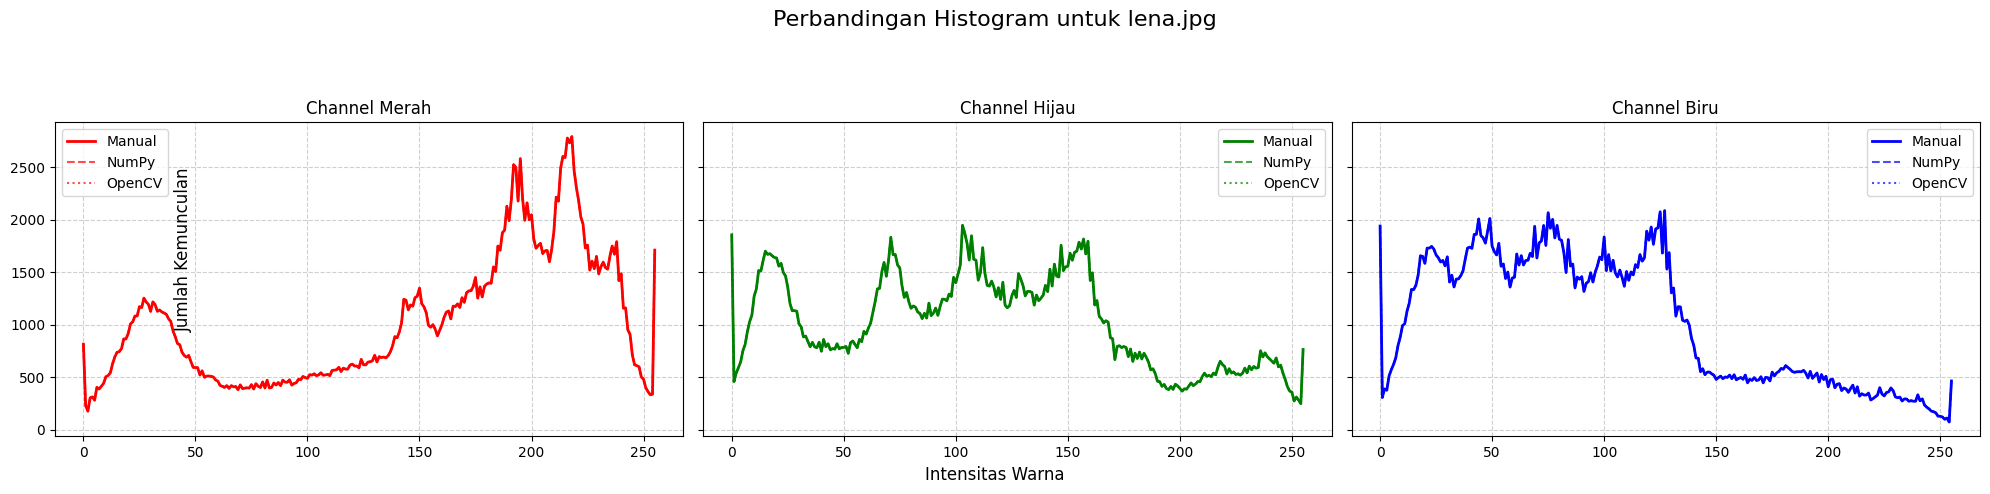


===== Memulai Pemrosesan Citra KTM1b.jpg =====
Menghitung histogram untuk KTM1b.jpg...

--- Perbandingan Histogram untuk KTM1b.jpg ---

Channel Merah:
  Selisih Maksimum (Manual vs NumPy): 0
  Selisih Maksimum (Manual vs OpenCV): 0.0
  Pembuktian berhasil: Selisih untuk channel Merah adalah nol.

Channel Hijau:
  Selisih Maksimum (Manual vs NumPy): 0
  Selisih Maksimum (Manual vs OpenCV): 0.0
  Pembuktian berhasil: Selisih untuk channel Hijau adalah nol.

Channel Biru:
  Selisih Maksimum (Manual vs NumPy): 0
  Selisih Maksimum (Manual vs OpenCV): 0.0
  Pembuktian berhasil: Selisih untuk channel Biru adalah nol.


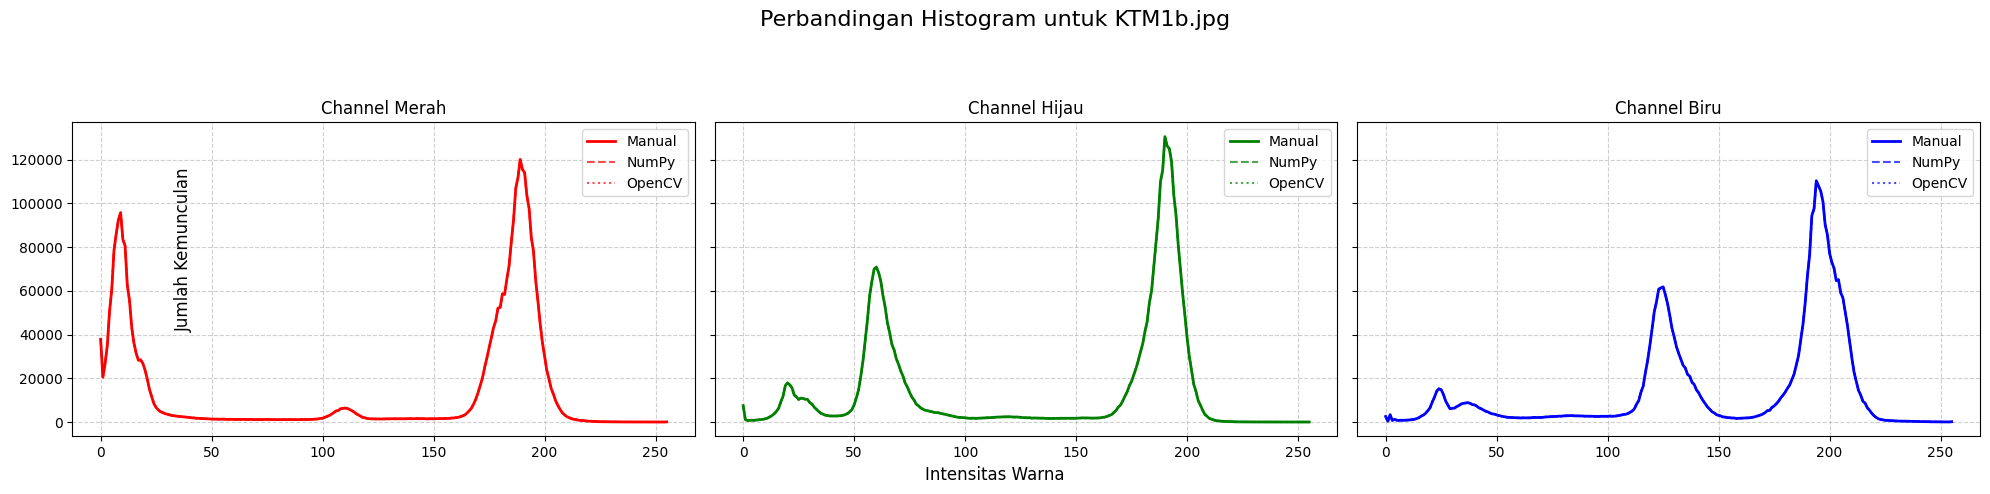

In [ ]:
# --- Fungsi Pembantu untuk Perhitungan Histogram ---

def calculate_manual_histogram_rgb(image_rgb):
    """
    Menghitung histogram untuk setiap channel RGB secara manual.
    Input: image_rgb (numpy.ndarray) - citra RGB
    Output: (hist_r, hist_g, hist_b) (tuple dari numpy.ndarray) - histogram untuk channel Merah, Hijau, Biru
    """
    height, width, _ = image_rgb.shape
    hist_r = np.zeros(256, dtype=int)
    hist_g = np.zeros(256, dtype=int)
    hist_b = np.zeros(256, dtype=int)

    for y in range(height):
        for x in range(width):
            hist_r[image_rgb[y, x, 0]] += 1
            hist_g[image_rgb[y, x, 1]] += 1
            hist_b[image_rgb[y, x, 2]] += 1
    return hist_r, hist_g, hist_b

def calculate_numpy_histogram_rgb(image_rgb):
    """
    Menghitung histogram untuk setiap channel RGB menggunakan numpy.histogram.
    Input: image_rgb (numpy.ndarray) - citra RGB
    Output: (hist_r, hist_g, hist_b) (tuple dari numpy.ndarray) - histogram untuk channel Merah, Hijau, Biru
    """
    # np.histogram mengembalikan nilai histogram dan bin edges. Kita hanya perlu nilai histogram.
    hist_r, _ = np.histogram(image_rgb[:,:,0].flatten(), bins=256, range=[0,256])
    hist_g, _ = np.histogram(image_rgb[:,:,1].flatten(), bins=256, range=[0,256])
    hist_b, _ = np.histogram(image_rgb[:,:,2].flatten(), bins=256, range=[0,256])
    return hist_r, hist_g, hist_b

def calculate_opencv_histogram_rgb(image_rgb):
    """
    Menghitung histogram untuk setiap channel RGB menggunakan cv.calcHist.
    Input: image_rgb (numpy.ndarray) - citra RGB
    Output: (hist_r, hist_g, hist_b) (tuple dari numpy.ndarray) - histogram untuk channel Merah, Hijau, Biru
    """
    # cv.calcHist memerlukan list gambar, indeks channel, mask, ukuran bin, dan rentang.
    # .flatten() digunakan untuk mengubah output menjadi array 1D.
    hist_r = cv.calcHist([image_rgb], [0], None, [256], [0,256]).flatten()
    hist_g = cv.calcHist([image_rgb], [1], None, [256], [0,256]).flatten()
    hist_b = cv.calcHist([image_rgb], [2], None, [256], [0,256]).flatten()
    return hist_r, hist_g, hist_b

def compare_and_display_histograms(title, manual_hists, numpy_hists, opencv_hists):
    """
    Membandingkan histogram dari berbagai metode, mencetak selisih maksimum, dan menampilkan plot.
    """
    print(f"\n--- Perbandingan Histogram untuk {title} ---")
    channels = ['Merah', 'Hijau', 'Biru']
    colors = ['red', 'green', 'blue']

    # Membandingkan dan mencetak selisih maksimum
    for i, channel in enumerate(channels):
        diff_manual_np = np.max(np.abs(manual_hists[i] - numpy_hists[i]))
        diff_manual_cv = np.max(np.abs(manual_hists[i] - opencv_hists[i]))
        print(f"\nChannel {channel}:")
        print(f"  Selisih Maksimum (Manual vs NumPy): {diff_manual_np}")
        print(f"  Selisih Maksimum (Manual vs OpenCV): {diff_manual_cv}")

        # Verifikasi bahwa selisihnya nol
        if diff_manual_np == 0 and diff_manual_cv == 0:
            print(f"  Pembuktian berhasil: Selisih untuk channel {channel} adalah nol.")
        else:
            print(f"  PERINGATAN: Selisih tidak nol untuk channel {channel}. Ada perbedaan antara metode.")

    # Plotting untuk konfirmasi visual
    fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
    fig.suptitle(f'Perbandingan Histogram untuk {title}', fontsize=16)
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical', fontsize=12)
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center', fontsize=12)

    for i, channel in enumerate(channels):
        # Plot ketiga histogram pada subplot yang sama untuk setiap channel
        axs[i].plot(manual_hists[i], color=colors[i], label='Manual', linewidth=2)
        axs[i].plot(numpy_hists[i], color=colors[i], linestyle='--', label='NumPy', alpha=0.7)
        axs[i].plot(opencv_hists[i], color=colors[i], linestyle=':', label='OpenCV', alpha=0.7)
        axs[i].set_title(f'Channel {channel}')
        axs[i].legend()
        axs[i].grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0.05, 1, 0.9]) # Sesuaikan layout agar judul tidak tumpang tindih
    plt.show()

# --- Bagian Utama: Memproses lena.jpg ---

print("\n===== Memulai Pemrosesan Citra lena.jpg =====")
# Citra 'img' dari sel sebelumnya adalah 'lena.jpg' yang sudah diubah ke format RGB
img_lena_rgb = img

if img_lena_rgb is None:
    print("Error: Citra 'lena.jpg' tidak dapat dimuat atau tidak tersedia dari sel sebelumnya.")
else:
    print("Menghitung histogram untuk lena.jpg...")
    # Hitung histogram menggunakan ketiga metode
    hist_r_manual_lena, hist_g_manual_lena, hist_b_manual_lena = calculate_manual_histogram_rgb(img_lena_rgb)
    hist_r_np_lena, hist_g_np_lena, hist_b_np_lena = calculate_numpy_histogram_rgb(img_lena_rgb)
    hist_r_cv_lena, hist_g_cv_lena, hist_b_cv_lena = calculate_opencv_histogram_rgb(img_lena_rgb)

    # Bandingkan dan tampilkan hasil untuk lena.jpg
    compare_and_display_histograms(
        "lena.jpg",
        (hist_r_manual_lena, hist_g_manual_lena, hist_b_manual_lena),
        (hist_r_np_lena, hist_g_np_lena, hist_b_np_lena),
        (hist_r_cv_lena, hist_g_cv_lena, hist_b_cv_lena)
    )

# --- Bagian Utama: Memproses KTM1b.jpg ---

print("\n===== Memulai Pemrosesan Citra KTM1b.jpg =====")
# Muat citra KTM1b.jpg
img_ktm_bgr = cv.imread(str(PATH / "KTM1b.jpg"))

if img_ktm_bgr is None:
    print("Error: Citra 'KTM1b.jpg' tidak dapat dimuat. Pastikan file ada di path yang ditentukan.")
else:
    img_ktm_rgb = cv.cvtColor(img_ktm_bgr, cv.COLOR_BGR2RGB)
    print("Menghitung histogram untuk KTM1b.jpg...")
    # Hitung histogram menggunakan ketiga metode
    hist_r_manual_ktm, hist_g_manual_ktm, hist_b_manual_ktm = calculate_manual_histogram_rgb(img_ktm_rgb)
    hist_r_np_ktm, hist_g_np_ktm, hist_b_np_ktm = calculate_numpy_histogram_rgb(img_ktm_rgb)
    hist_r_cv_ktm, hist_g_cv_ktm, hist_b_cv_ktm = calculate_opencv_histogram_rgb(img_ktm_rgb)

    # Bandingkan dan tampilkan hasil untuk KTM1b.jpg
    compare_and_display_histograms(
        "KTM1b.jpg",
        (hist_r_manual_ktm, hist_g_manual_ktm, hist_b_manual_ktm),
        (hist_r_np_ktm, hist_g_np_ktm, hist_b_np_ktm),
        (hist_r_cv_ktm, hist_g_cv_ktm, hist_b_cv_ktm)
    )

2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.


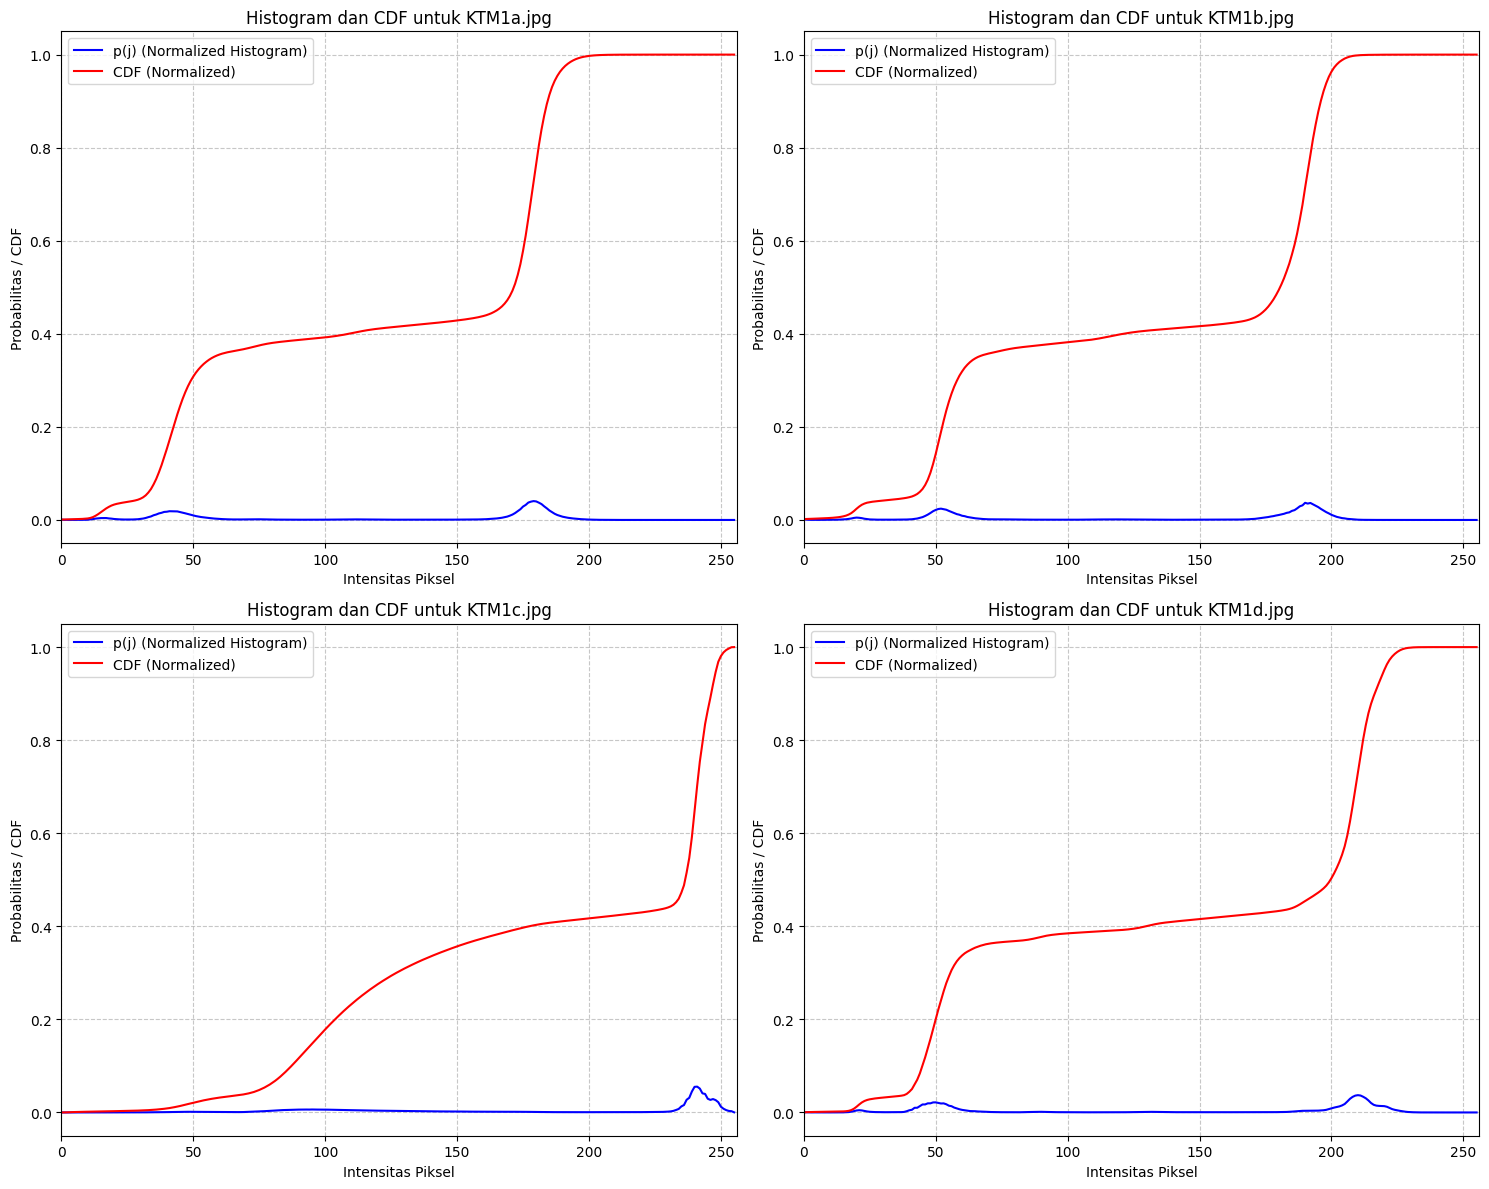

In [ ]:
image_files = [
    PATH / "KTM1a.jpg",
    PATH / "KTM1b.jpg",
    PATH / "KTM1c.jpg",
    PATH / "KTM1d.jpg",
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Meratakan array axes agar mudah diiterasi

for i, img_path in enumerate(image_files):
    img_bgr = cv.imread(str(img_path))

    if img_bgr is None:
        print(f"Error: Tidak dapat memuat citra {img_path}")
        continue

    # Konversi ke citra grayscale
    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    # Hitung histogram
    hist = cv.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()

    # Hitung histogram ternormalisasi (p(j)) - Probability Distribution Function
    # Jumlah total piksel dalam citra
    total_pixels = img_gray.shape[0] * img_gray.shape[1]
    hist_normalized = hist / total_pixels

    # Hitung Cumulative Distribution Function (CDF)
    cdf = hist.cumsum()
    cdf_normalized = cdf / cdf.max() # Normalisasi CDF ke 0-1

    # Plotting
    ax = axes[i]
    ax.set_title(f'Histogram dan CDF untuk {img_path.name}')
    ax.set_xlabel('Intensitas Piksel')
    ax.set_ylabel('Probabilitas / CDF')
    ax.set_xlim([0, 256])

    # Plot histogram ternormalisasi p(j)
    ax.plot(hist_normalized, color='blue', label='p(j) (Normalized Histogram)')

    # Plot kurva CDF
    ax.plot(cdf_normalized, color='red', label='CDF (Normalized)')

    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

 **Penjelasan Perbedaan Kurva CDF**

Kurva CDF menunjukkan sebaran kecerahan dalam sebuah gambar. Berikut adalah cara menginterpretasikan perbedaannya:

*   **Citra Paling Gelap (misal: KTM1a.jpg)**:
    *   Kurva CDF akan **naik tajam di awal (nilai intensitas rendah)** dan kemudian cenderung mendatar. Ini berarti sebagian besar piksel memiliki nilai gelap.
    *   **Kaitan dengan Pencahayaan**: Ini menandakan citra `underexposed` (kurang cahaya), di mana detail di area gelap mungkin hilang.

*   **Citra Paling Terang (misal: KTM1d.jpg)**:
    *   Kurva CDF akan **naik lebih lambat di awal** dan baru **naik tajam di akhir (nilai intensitas tinggi)**. Ini berarti sebagian besar piksel memiliki nilai terang.
    *   **Kaitan dengan Pencahayaan**: Ini menandakan citra `overexposed` (kelebihan cahaya), di mana detail di area terang (highlight) mungkin hilang karena piksel mencapai nilai maksimum (putih).

Secara umum, citra dengan **kontras dan pencahayaan yang baik** akan memiliki kurva CDF yang **naik lebih merata** di sepanjang rentang intensitas, menunjukkan distribusi piksel yang lebih seimbang dari gelap ke terang.

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.